In [1]:
import pandas as pd
import re
import numpy as np
from io import StringIO   # <-- use isto
import matplotlib.pyplot as plt

# Tratamento de Dados

In [3]:
arquivo = "vib_mode.txt"

with open(arquivo, "r") as f:
    linhas = f.readlines()

# --------------------
# 1) Parte inicial (159 linhas)
# --------------------

linhas_159 = linhas[:159]

header = re.split(r"\s+", linhas[0].strip())
header = [h for h in header if h != ""]

df = pd.read_csv(
    StringIO("".join(linhas_159)),
    delim_whitespace=True,
    names=header,
    skiprows=1
)

# --------------------
# 2) Blocos seguintes
# --------------------

blocos = []
i = 159

num_regex = r"^\s*\d+(\s+\d+)*\s*$"

while i < len(linhas):

    # Linha com números das colunas
    col_header_line = linhas[i].strip()
    novas_cols = re.split(r"\s+", col_header_line)
    novas_cols = [c for c in novas_cols if c != ""]
    i += 1

    bloco_linhas = []

    # Acumular linhas do bloco
    while i < len(linhas) and not re.match(num_regex, linhas[i]):
        bloco_linhas.append(linhas[i])
        i += 1

    # Se não houver linhas, pula
    if len(bloco_linhas) == 0:
        continue

    # ----------------------------
    # Detectar número real de colunas no bloco
    # ----------------------------
    primeira_linha = bloco_linhas[0].strip()
    ncols = len(re.split(r"\s+", primeira_linha))

    # criar nomes para todas as colunas
    # primeira é índice, outras são novas_cols (até onde existirem)
    nomes = ["idx"] + novas_cols + [f"extra_{k}" for k in range(len(novas_cols)+1, ncols)]

    df_bloco = pd.read_csv(
        StringIO("".join(bloco_linhas)),
        delim_whitespace=True,
        names=nomes
    )

    df_bloco = df_bloco.drop(columns=["idx"])
    blocos.append(df_bloco)

# --------------------
# 3) Concatenar
# --------------------

for b in blocos:
    df = pd.concat([df, b], axis=1)

C:\Users\55219\AppData\Local\Temp\ipykernel_20000\891586951.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_20000\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_20000\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_20000\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_20000\891586951.py:60:

In [5]:
def renomear_index_por_atom(df, lista_atomica):
    """
    df: DataFrame final já criado (159 linhas)
    lista_atomica: lista de strings com linhas contendo símbolo, massa e coordenadas
    """
    # Extrair apenas o símbolo atômico de cada linha
    simbolos = [linha.split()[0] for linha in lista_atomica]

    novo_index = []
    contadores = {}  # exemplo: {"C":1, "H":1, "O":1}

    for simbolo in simbolos:
        if simbolo not in contadores:
            contadores[simbolo] = 1

        nome = f"{simbolo}{contadores[simbolo]}"

        # Cada átomo corresponde a 3 linhas do DataFrame
        novo_index.extend([nome, nome, nome])

        contadores[simbolo] += 1

    # Aplicar ao DataFrame
    df.index = novo_index
    return df

In [7]:
lista_atomica = [
    "C     12.01100     -5.520264845720    -1.115707479413     0.897605357711",
    "C     12.01100      5.520452518574    -1.115723577676    -0.897303843581",
    "C     12.01100     -4.717428065189    -2.832744402920    -1.052293345657",
    "C     12.01100      4.717889260456    -2.832871384362     1.052539744557",
    "C     12.01100     -6.606891583710    -4.394353536396    -2.145371212533",
    "C     12.01100      6.607390344081    -4.394770037602     2.145057663476",
    "H      1.00800     -6.034676638152    -5.702671048362    -3.610513207819",
    "H      1.00800      6.035355292474    -5.703243699406     3.610128208214",
    "C     12.01100     -9.066360064720    -4.254075940367    -1.367474199670",
    "C     12.01100      9.066728222324    -4.254628795559     1.366661179528",
    "H      1.00800    -10.511265866955    -5.441454535473    -2.193507432040",
    "H      1.00800     10.511683451023    -5.442288278089     2.192214608511",
    "C     12.01100     -9.770578178244    -2.550150813499     0.537008619724",
    "C     12.01100      9.770715542304    -2.550563288206    -0.537744580628",
    "C     12.01100     -8.020310169408    -0.994075397066     1.671451991949",
    "C     12.01100      8.020340638195    -0.994159763824    -1.671623622263",
    "N     14.00700    -12.378556223629    -2.409089787803     1.327755332438",
    "N     14.00700     12.378519201596    -2.409668247301    -1.329083667815",
    "O     15.99900     -2.416219571234    -2.903288706253    -1.747879105684",
    "O     15.99900      2.416744722791    -2.903297471670     1.748496268000",
    "O     15.99900    -13.888079551984    -3.808782207744     0.304531482779",
    "O     15.99900     13.888086558489    -3.809858819272    -0.306655649681",
    "O     15.99900    -12.928247729108    -0.893379703175     2.972383430461",
    "O     15.99900     12.927953998234    -0.893763939771    -2.973651371779",
    "N     14.00700     -3.564693824940     0.330596326795     1.821477061978",
    "N     14.00700      3.564735878326     0.330650146953    -1.820781402117",
    "H      1.00800     -8.649557134583     0.282766099379     3.140249066382",
    "H      1.00800      8.649412269810     0.282821974285    -3.140385031032",
    "C     12.01100     -3.655291153411     2.031063880783     3.536851991090",
    "C     12.01100      3.655056986834     2.030838091497    -3.536441828175",
    "H      1.00800     -5.377071945919     2.549964151628     4.541848489297",
    "C     12.01100     -1.310384408628     3.291486455883     4.191970491532",
    "C     12.01100      1.310046939264     3.291108840358    -4.191443794614",
    "H      1.00800      5.376641385352     2.549464552762    -4.541919460723",
    "N     14.00700      0.741387328905     2.577206192449     2.876254138590",
    "C     12.01100     -1.181804924987     5.094014086095     6.099820375343",
    "C     12.01100      1.181227147302     5.093277810341    -6.099625154786",
    "N     14.00700     -0.741599888669     2.576856952799    -2.875508194828",
    "C     12.01100      2.955085757498     3.593295877611     3.458276208785",
    "H      1.00800     -2.881312278661     5.626521498741     7.109401298976",
    "C     12.01100      1.133402062841     6.155165171408     6.683444521954",
    "H      1.00800      2.880649251831     5.625718623776    -7.109394845466",
    "C     12.01100     -1.134093225637     6.154099585433    -6.683384268274",
    "C     12.01100     -2.955402360777     3.592657946625    -3.457669967266",
    "H      1.00800      4.565823766006     2.942241245285     2.371070162337",
    "C     12.01100      3.249950073085     5.383762691732     5.348576630598",
    "H      1.00800      1.287843102082     7.556621529536     8.167726618197",
    "C     12.01100     -3.250503942796     5.382767012137    -5.348272220948",
    "H      1.00800     -1.288716667155     7.555250245205    -8.167932773460",
    "H      1.00800     -4.566072050899     2.941572288416    -2.370400223201",
    "H      1.00800      5.104212185344     6.145690387923     5.751937690401",
    "H      1.00800     -5.104864181243     6.144415297879    -5.751727712650",
    "Fe    55.85000      0.000239285754    -0.441112578978     0.000655619575"
]

In [9]:
df = renomear_index_por_atom(df, lista_atomica)

In [11]:
df

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.019106,-0.039230,0.009616,0.024391,...,-2.595860e-04,0.000002,-0.000026,0.000085,-0.003093,-1.719612e-06,-0.000015,0.000035,-0.000006,-0.000087
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.006584,0.023458,0.046524,-0.023121,...,-1.173026e-05,0.000001,-0.000010,0.000031,-0.000433,7.614580e-07,-0.000003,0.000046,0.000012,0.000166
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.013680,-0.035872,-0.014598,0.031412,...,1.501361e-04,0.000002,-0.000009,-0.000009,0.001195,6.678394e-07,-0.000013,0.000035,0.000017,0.000238
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.019196,-0.039119,-0.009400,0.019897,...,-1.193453e-05,-0.000259,0.000085,-0.000014,-0.000005,3.090759e-03,-0.000034,0.000014,-0.000086,0.000006
C2,0.0,0.0,0.0,0.0,0.0,0.0,-0.006419,-0.023211,0.046624,0.003547,...,-8.430523e-07,0.000013,-0.000031,0.000005,0.000002,-4.316002e-04,0.000046,-0.000001,-0.000166,0.000011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H16,0.0,0.0,0.0,0.0,0.0,0.0,-0.141380,0.150821,-0.096255,-0.144908,...,9.478915e-04,-0.000734,0.130404,0.008370,0.003757,-2.321517e-03,0.416670,0.007414,-0.000452,-0.000375
H16,0.0,0.0,0.0,0.0,0.0,0.0,0.001895,-0.042711,-0.168881,-0.063116,...,-1.877216e-04,0.000142,-0.028402,-0.001843,-0.000745,4.858897e-04,-0.083486,-0.001487,0.000089,0.000067
Fe1,0.0,0.0,0.0,0.0,0.0,0.0,0.000021,-0.036703,0.000086,0.017409,...,-2.533183e-05,-0.000024,0.000002,0.000002,-0.000015,1.527695e-05,0.000010,-0.000010,-0.000004,-0.000004
Fe1,0.0,0.0,0.0,0.0,0.0,0.0,-0.063798,0.000102,0.075838,-0.005241,...,-1.128576e-05,0.000012,-0.000003,0.000003,0.000004,4.390679e-06,0.000020,0.000021,-0.000002,0.000002


In [27]:
(df['153']**2).sum()

1.000000000008345

# Plot

In [14]:
df

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.019106,-0.039230,0.009616,0.024391,...,-2.595860e-04,0.000002,-0.000026,0.000085,-0.003093,-1.719612e-06,-0.000015,0.000035,-0.000006,-0.000087
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.006584,0.023458,0.046524,-0.023121,...,-1.173026e-05,0.000001,-0.000010,0.000031,-0.000433,7.614580e-07,-0.000003,0.000046,0.000012,0.000166
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.013680,-0.035872,-0.014598,0.031412,...,1.501361e-04,0.000002,-0.000009,-0.000009,0.001195,6.678394e-07,-0.000013,0.000035,0.000017,0.000238
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.019196,-0.039119,-0.009400,0.019897,...,-1.193453e-05,-0.000259,0.000085,-0.000014,-0.000005,3.090759e-03,-0.000034,0.000014,-0.000086,0.000006
C2,0.0,0.0,0.0,0.0,0.0,0.0,-0.006419,-0.023211,0.046624,0.003547,...,-8.430523e-07,0.000013,-0.000031,0.000005,0.000002,-4.316002e-04,0.000046,-0.000001,-0.000166,0.000011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H16,0.0,0.0,0.0,0.0,0.0,0.0,-0.141380,0.150821,-0.096255,-0.144908,...,9.478915e-04,-0.000734,0.130404,0.008370,0.003757,-2.321517e-03,0.416670,0.007414,-0.000452,-0.000375
H16,0.0,0.0,0.0,0.0,0.0,0.0,0.001895,-0.042711,-0.168881,-0.063116,...,-1.877216e-04,0.000142,-0.028402,-0.001843,-0.000745,4.858897e-04,-0.083486,-0.001487,0.000089,0.000067
Fe1,0.0,0.0,0.0,0.0,0.0,0.0,0.000021,-0.036703,0.000086,0.017409,...,-2.533183e-05,-0.000024,0.000002,0.000002,-0.000015,1.527695e-05,0.000010,-0.000010,-0.000004,-0.000004
Fe1,0.0,0.0,0.0,0.0,0.0,0.0,-0.063798,0.000102,0.075838,-0.005241,...,-1.128576e-05,0.000012,-0.000003,0.000003,0.000004,4.390679e-06,0.000020,0.000021,-0.000002,0.000002


In [50]:
atomos = [('O1',15.99900),('O2',15.99900),('N3',14.00700),('N4',14.00700),('N5',14.00700),('N6',14.00700),('Fe1',55.85000)]
#atomos = [('O1',1),('O2',1),('N3',1),('N4',1),('N5',1),('N6',1),('Fe1',1)]
atomos_tot = [
("C1", 12.01100),
("C2", 12.01100),
("C3", 12.01100),
("C4", 12.01100),
("C5", 12.01100),
("C6", 12.01100),
("H1", 1.00800),
("H2", 1.00800),
("C7", 12.01100),
("C8", 12.01100),
("H3", 1.00800),
("H4", 1.00800),
("C9", 12.01100),
("C10", 12.01100),
("C11", 12.01100),
("C12", 12.01100),
("N1", 14.00700),
("N2", 14.00700),
("O1", 15.99900),
("O2", 15.99900),
("O3", 15.99900),
("O4", 15.99900),
("O5", 15.99900),
("O6", 15.99900),
("N3", 14.00700),
("N4", 14.00700),
("H5", 1.00800),
("H6", 1.00800),
("C13", 12.01100),
("C14", 12.01100),
("H7", 1.00800),
("C15", 12.01100),
("C16", 12.01100),
("H8", 1.00800),
("N5", 14.00700),
("C17", 12.01100),
("C18", 12.01100),
("N6", 14.00700),
("C19", 12.01100),
("H9", 1.00800),
("C20", 12.01100),
("H10", 1.00800),
("C21", 12.01100),
("C22", 12.01100),
("H11", 1.00800),
("C23", 12.01100),
("H12", 1.00800),
("C24", 12.01100),
("H13", 1.00800),
("H14", 1.00800),
("H15", 1.00800),
("H16", 1.00800),
("Fe1", 55.85000)
]


col = np.arange(0,159)

contr_atom = []
contr_atom_total = []

for j in col:
    soma_modo = 0.0
    soma_modo_total = 0
    for at in atomos:
        #val = at[1]*((df.loc[str(at[0])]**2)[str(j)]).sum()
        val = ((df.loc[str(at[0])]**2)[str(j)]).sum()
        soma_modo += val
        #print(at[0],at[1],str(j))
    for at in atomos_tot:
        #val_tot = at[1]*((df.loc[str(at[0])]**2)[str(j)]).sum()
        val_tot = ((df.loc[str(at[0])]**2)[str(j)]).sum()
        soma_modo_total += val_tot
        #print(at[0],at[1],str(j))
    contr_atom.append(soma_modo)
    contr_atom_total.append(soma_modo_total)


In [52]:
Oct = np.array(contr_atom[6:])
Tot = np.array(contr_atom_total[6:])

Contr_oct = Oct/Tot

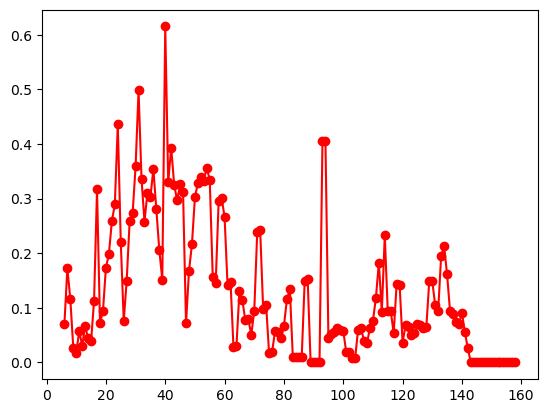

In [20]:
plt.plot(col[6:], Contr_oct,marker='o',color='red')
plt.show()

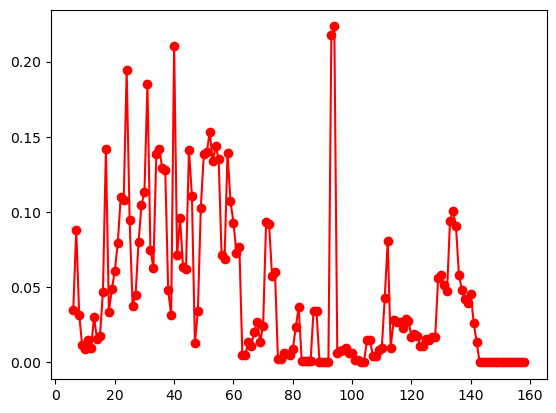

In [54]:
plt.plot(col[6:], Contr_oct,marker='o',color='red')
plt.show()

In [33]:
len(valores)

153

In [36]:
Contr_oct_df = pd.read_csv("Oct_Contri.csv")

In [44]:
Contr_oct_df['modos'] = valores2

In [46]:
Contr_oct_df

,index,valor,array,modos
0,6,16.800836,0.069548,16.800836
1,7,24.615750,0.172795,24.615750
2,8,38.347452,0.116668,38.347452
3,9,49.869031,0.027723,49.869031
4,10,50.774919,0.017137,50.774919
...,...,...,...,...
148,154,3229.938790,0.000004,3229.938790
149,155,3233.978123,0.000009,3233.978123
150,156,3234.192034,0.000009,3234.192034
151,157,3238.249430,0.000002,3238.249430


In [39]:
Contr_oct_df.sort_values(by=['array'],ascending=False)[:15]

,index,valor,array,modos
40,46,503.755440,0.629462,503.755440
39,45,495.166305,0.570897,495.166305
13,19,125.695132,0.518842,125.695132
20,26,204.769199,0.484549,204.769199
21,27,241.390250,0.473349,241.390250
15,21,144.435391,0.454171,144.435391
18,24,170.835434,0.431847,170.835434
19,25,180.125616,0.408547,180.125616
22,28,248.508294,0.389942,248.508294
88,94,1031.867542,0.385721,1031.867542


In [48]:
Contr_oct_df.to_csv('your_file_name.csv', index=False)